In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pd.set_option("display.float_format", "{:.2f}".format)
df = pd.read_parquet("/content/drive/MyDrive/dataset-dataEng./fhvhv_tripdata_2025-07.parquet")

In [4]:
df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2025-07-01 00:05:56,2025-07-01 00:08:03,2025-07-01 00:08:44,2025-07-01 00:28:42,65,179,9.93,...,0.00,0.00,0.00,26.11,N,N,N,N,N,0.00
1,HV0005,B03406,None,2025-07-01 00:09:38,2025-07-01 00:16:28,2025-07-01 00:17:28,2025-07-01 00:22:50,35,35,0.79,...,0.00,0.00,0.00,4.39,N,N,N,N,N,0.00
2,HV0003,B03404,B03404,2025-07-01 00:47:47,2025-07-01 00:51:20,2025-07-01 00:51:20,2025-07-01 01:04:56,233,143,3.05,...,2.75,0.00,0.00,12.53,N,N,N,N,N,1.50
3,HV0005,B03406,None,2025-07-01 00:05:36,2025-07-01 00:08:46,2025-07-01 00:09:18,2025-07-01 00:28:44,68,145,3.99,...,2.75,0.00,0.00,19.06,N,N,N,N,Y,1.50
4,HV0005,B03406,None,2025-07-01 00:10:04,2025-07-01 00:35:56,2025-07-01 00:35:58,2025-07-01 01:09:06,132,90,17.70,...,2.75,2.50,0.00,45.22,N,N,N,N,N,1.50


Data Cleaning Anleitung (Adım Adım)
1. Eksik değerler (NaN)

Kod:

df.isna().sum()


Karar:

Çok azsa → satır sil (df.dropna())

Orta düzeyse → doldur (fillna(mean/median/mode/Unknown))

Çok fazlaysa → sütunu at (df.drop(columns=...))

In [10]:
df.isna().sum()


,0
hvfhs_license_num,0
dispatching_base_num,0
originating_base_num,5492276
request_datetime,0
on_scene_datetime,0
pickup_datetime,0
dropoff_datetime,0
PULocationID,0
DOLocationID,0
trip_miles,0


kod calismio ama origatning bas estununu atmak istedim..

In [ ]:
df.drop(columns="originating_base_num")

In [6]:
df_test = df.dropna(subset=["originating_base_num"])


In [7]:
df_test["dispatch_origin_equal"] = (
    df_test["dispatching_base_num"] == df_test["originating_base_num"]
)


/tmp/ipython-input-645969879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["dispatch_origin_equal"] = (


In [9]:
df_test.groupby("dispatch_origin_equal")["driver_pay"].mean()


,driver_pay
dispatch_origin_equal,
False,20.49
True,21.16


In [5]:
df_test.groupby("dispatch_origin_equal")["driver_pay"].agg(["count", "mean", "median"])


NameError: name 'df_test' is not defined

okey dispac stunu yeterli, cnku oriatng ve dipsatch esit olmadgi yerlede anlamli ucret farki yok ,obwohl 47 satr bilgi olmasina ragmen elimizde. ama istatsgni yaptik p degeri anlamli istatstik deger olamdgni gosterio.

In [4]:
from scipy import stats

same = df_test.loc[df_test["dispatch_origin_equal"], "driver_pay"].dropna()
diff = df_test.loc[~df_test["dispatch_origin_equal"], "driver_pay"].dropna()

t_stat, p_value = stats.ttest_ind(same, diff, equal_var=False)
print("t-istatistik:", t_stat, "p-değeri:", p_value)


NameError: name 'df_test' is not defined

yani burdan data cleaning dewamke(: baska ne war bakalim?? origatng belki df den silcez..cnku bise katmio gbi gbi bi cok acidan,onu uzun uzun anlatrm.
Eksikler → Mantıksızlar → Tipler → Duplicate → Outlier → Kolon düzeni → Konsistenz kontrol → Son kontrol.

2. Mantıksız değerler

Burada “gerçek hayatta olamaz” durumları buluyoruz:

Ne olmuş?

trip_miles < 0 → hiç satır yakalamadı ✅

trip_time <= 0 → hiç satır yakalamadı ✅

driver_pay < 0 → hiç satır yok ✅

tips < 0 → hiç satır yok ✅

(driver_pay == 0) & (trip_miles > 5) → senin tablonu oluşturan tek koşul bu

Yani: şu ana kadar tek sorunlu grup driver_pay = 0 olan, ama aslında mil ve süre > 0 olan yolculuklar.

In [8]:
df[df["trip_miles"] < 0]
df[df["trip_time"] <= 0]
df[df["driver_pay"] < 0]
df[df["tips"] < 0]
df[(df["driver_pay"] == 0) & (df["trip_miles"] > 5)]


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
99804,HV0003,B03404,B03404,2025-07-01 07:44:41,2025-07-01 07:47:56,2025-07-01 07:49:56,2025-07-01 08:27:28,80,100,6.25,...,2.75,0.00,0.00,0.00,N,N,N,N,N,0.00
110815,HV0005,B03406,None,2025-07-01 08:53:01,2025-07-01 08:58:18,2025-07-01 08:59:02,2025-07-01 09:34:36,97,68,5.67,...,0.75,0.00,0.00,0.00,Y,N,N,N,N,1.50
117899,HV0003,B03404,B03404,2025-07-01 08:23:11,2025-07-01 08:24:51,2025-07-01 08:24:51,2025-07-01 08:48:34,208,126,6.28,...,0.00,0.00,0.00,0.00,N,N,N,N,N,0.00
204679,HV0003,B03404,B03404,2025-07-01 11:48:51,2025-07-01 11:55:02,2025-07-01 11:55:37,2025-07-01 12:27:57,228,21,5.64,...,0.00,0.00,0.00,0.00,N,N,N,N,N,0.00
235475,HV0003,B03404,B03404,2025-07-01 12:37:44,2025-07-01 12:38:53,2025-07-01 12:40:54,2025-07-01 13:30:30,76,37,5.59,...,0.00,0.00,0.00,0.00,N,N,N,N,N,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19419594,HV0005,B03406,None,2025-07-31 17:20:01,2025-07-31 17:28:50,2025-07-31 17:28:52,2025-07-31 18:55:21,68,241,14.53,...,0.75,0.00,0.00,0.00,Y,N,N,N,N,1.50
19459671,HV0005,B03406,None,2025-07-31 18:35:47,2025-07-31 18:43:46,2025-07-31 18:44:05,2025-07-31 19:32:11,68,265,5.44,...,0.00,0.00,0.00,0.00,Y,N,N,N,N,1.50
19466852,HV0005,B03406,None,2025-07-31 18:29:58,2025-07-31 18:43:09,2025-07-31 18:43:18,2025-07-31 19:12:04,68,82,7.41,...,0.75,0.00,0.00,0.00,Y,N,N,N,N,1.50
19549973,HV0005,B03406,None,2025-07-31 20:45:46,2025-07-31 20:49:00,2025-07-31 20:49:59,2025-07-31 21:18:11,246,1,18.89,...,0.00,1.25,0.00,0.00,Y,N,N,N,N,1.50


In [5]:
df["is_free_trip"] = df["driver_pay"] == 0


df_paid → şoför kazancı analizleri için,

df → orijinal (flag’li) tablo, hepsi duruyor.

In [6]:
df_paid = df[df["is_free_trip"] == False]


In [8]:
# 3. ADIM: Tip dönüşümleri

# --- Tarih kolonları (datetime formatına çevir) ---
date_cols = ["request_datetime", "on_scene_datetime", "pickup_datetime", "dropoff_datetime"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
        # errors="coerce" → çevrilemeyenleri NaT yapar
        # utc=True → standart format, gerekirse sonra local time zone yapabilirsin

# --- Sayısal kolonlar (numeric formatına çevir) ---
num_cols = [
    "PULocationID","DOLocationID","trip_miles","trip_time",
    "base_passenger_fare","tolls","bcf","sales_tax",
    "congestion_surcharge","airport_fee","tips","driver_pay",
    "cbd_congestion_fee"
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        # errors="coerce" → sayı olmayan değerleri NaN yapar

# --- Bayrak / kategorik kolonlar (category tipine çevir) ---
flag_cols = ["shared_request_flag","shared_match_flag",
             "access_a_ride_flag","wav_request_flag","wav_match_flag"]
for col in flag_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Şirket / base kolonlarını da kategorik yapabiliriz
cat_cols = ["hvfhs_license_num","dispatching_base_num","originating_base_num"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")


🌱 harika, çıktıyı çok güzel aldın! Şimdi **3. adım (tip dönüşümleri)** sonucunu yorumlayalım:

---

## 📌 Tarih/Saat sütunları

* `request_datetime`, `on_scene_datetime`, `pickup_datetime`, `dropoff_datetime` → `datetime64[us, UTC]` ✅
  → Artık bunlarla saat, gün, hafta bazında analiz yapabilirsin.

---

## 📌 Sayısal sütunlar

* `PULocationID`, `DOLocationID` → `Int64` (nullable int) ✅
* `trip_miles`, `base_passenger_fare`, `tolls`, `bcf`, `sales_tax`, `congestion_surcharge`, `airport_fee`, `tips`, `driver_pay`, `cbd_congestion_fee` → `float64` ✅
* `trip_time` → `int64` ✅

👉 Hepsi artık matematiksel işlemlere uygun.

---

## 📌 Kategorik / Bayrak sütunları

* `hvfhs_license_num`, `dispatching_base_num`, `originating_base_num` → `category` ✅
* `shared_request_flag`, `shared_match_flag`, `access_a_ride_flag`, `wav_request_flag`, `wav_match_flag` → `category` ✅

👉 Bunları ileride `value_counts()` ile özetleyebilir, grup analizlerinde kolay kullanabilirsin.

---

## 📌 Ekstra sütun

* `is_free_trip` → `bool` (senin flag’in) ✅

---

## 🎯 Genel Sonuç

* **Tüm tip dönüşümleri başarılı olmuş.**
* Artık dataset’in temiz bir şekilde sayısal, kategorik ve datetime sütunlarına ayrıldı.
* Bundan sonra duplicate kontrolü (4. adım) ve outlier bakışı (5. adım) için hazırız.

---

👉 Sence şimdi doğrudan **4. Duplicate kontrolü**ne mi geçelim, yoksa önce tip dönüşümlerinin çıktılarını biraz **keşfetme (ör. `df["pickup_datetime"].dt.hour.value_counts()`)** gibi küçük EDA adımları mı yapalım?


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19653012 entries, 0 to 19653011
Data columns (total 26 columns):
 #   Column                Dtype              
---  ------                -----              
 0   hvfhs_license_num     category           
 1   dispatching_base_num  category           
 2   originating_base_num  category           
 3   request_datetime      datetime64[us, UTC]
 4   on_scene_datetime     datetime64[us, UTC]
 5   pickup_datetime       datetime64[us, UTC]
 6   dropoff_datetime      datetime64[us, UTC]
 7   PULocationID          Int64              
 8   DOLocationID          Int64              
 9   trip_miles            float64            
 10  trip_time             int64              
 11  base_passenger_fare   float64            
 12  tolls                 float64            
 13  bcf                   float64            
 14  sales_tax             float64            
 15  congestion_surcharge  float64            
 16  airport_fee           float64     

In [10]:
# 4. Duplicate kontrolü

# Kaç tane duplicate (tam kopya satır) var?
dup_count = df.duplicated().sum()
print("Duplicate satır sayısı:", dup_count)

# Eğer varsa -> düşelim
if dup_count > 0:
    df = df.drop_duplicates()
    print("Drop sonrası satır sayısı:", len(df))
else:
    print("Duplicate yok, tablo aynı kaldı:", len(df))


Duplicate satır sayısı: 0
Duplicate yok, tablo aynı kaldı: 19653012


In [11]:
# 5. Aykırı değerler (outlier kontrolü)

# Sayısal sütunların özet istatistikleri
num_cols = [
    "trip_miles","trip_time","base_passenger_fare","tolls","bcf",
    "sales_tax","congestion_surcharge","airport_fee","tips","driver_pay","cbd_congestion_fee"
]

print("=== describe() özet istatistikleri ===")
print(df[num_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T)

# Çok uç değerleri manuel kontrol (örnek eşikler)
print("\n=== Uç değer kontrolü ===")
if "trip_miles" in df.columns:
    print("trip_miles > 200:", df[df["trip_miles"] > 200].shape[0])
if "driver_pay" in df.columns:
    print("driver_pay > 500:", df[df["driver_pay"] > 500].shape[0])


=== describe() özet istatistikleri ===
                           count    mean    std    min     1%     5%    50%  \
trip_miles           19653012.00    5.11   6.02   0.00   0.47   0.76   3.06   
trip_time            19653012.00 1188.20 858.32   1.00 192.00 304.00 967.00   
base_passenger_fare  19653012.00   26.57  24.87 -35.91   6.04   7.66  18.98   
tolls                19653012.00    1.10   3.59   0.00   0.00   0.00   0.00   
bcf                  19653012.00    0.67   0.65   0.00   0.13   0.18   0.47   
sales_tax            19653012.00    2.21   2.04   0.00   0.00   0.54   1.60   
congestion_surcharge 19653012.00    0.95   1.30   0.00   0.00   0.00   0.00   
airport_fee          19653012.00    0.22   0.72   0.00   0.00   0.00   0.00   
tips                 19653012.00    1.17   3.56   0.00   0.00   0.00   0.00   
driver_pay           19653012.00   20.73  18.46 -35.38   4.00   4.72  15.42   
cbd_congestion_fee   19653012.00    0.51   0.71   0.00   0.00   0.00   0.00   

            

Sonuç: İkisini birlikte yap

Flag ekle → uç değerler kaybolmasın, istersen ayrıca analiz et.

Ayrıca temiz subset oluştur → şoför kazancı ile ilgili User Story’lerde bunu kullan.

Böylece:

Angebot & Nachfrage analizi → df (flag’lerle, hiçbir satır kaybolmadı)

Einnahmen / Lohn analizi → df_clean (uç değerlerden arındırılmış)

In [12]:
# Flag ekle
df["is_outlier_miles"] = df["trip_miles"] > 200
df["is_outlier_pay"]   = df["driver_pay"] > 500

# Temiz dataset (kazanç analizleri için)
df_clean = df[(df["is_outlier_miles"] == False) & (df["is_outlier_pay"] == False)].copy()

print("Orijinal veri:", len(df))
print("Temiz (kazanç analizi için) veri:", len(df_clean))


Orijinal veri: 19653012
Temiz (kazanç analizi için) veri: 19652763


şimdi 6. Kolon düzenleme adımındayız.

Burada iki şey yapıyoruz:

Gereksiz / çok eksik kolonları çıkarmak (şimdilik originating_base_num).

(İstersen) kolon isimlerini düzenlemek / Türkçeleştirmek.

In [13]:
if "originating_base_num" in df.columns:
    df = df.drop(columns=["originating_base_num"])
    df_clean = df_clean.drop(columns=["originating_base_num"], errors="ignore")


1. Zaman sırası testi

Bir yolculukta:
pickup_datetime < dropoff_datetime olmalı.
Eğer >0 çıkarsa → bu satırlarda mantık hatası var (ör. inme zamanı binmeden önce).
Çözüm: genelde bu satırları silmek gerekir.

In [14]:
# pickup > dropoff olan anormal satırları bul
time_errors = df[
    (df["pickup_datetime"].notna()) &
    (df["dropoff_datetime"].notna()) &
    (df["pickup_datetime"] > df["dropoff_datetime"])
]

print("Zaman sırası hatalı satır sayısı:", len(time_errors))


Zaman sırası hatalı satır sayısı: 0


2. Lokasyon ID kontrolü

Her yolculuğun bir başlangıç (PULocationID) ve bitiş (DOLocationID) yeri olmalı.

Eğer 0 veya NaN ise → sorunlu olabilir.

Tüm yolculukların hem PULocationID (pickup) hem DOLocationID (dropoff) düzgün kaydedilmiş.

👉 Bu veri açısından çok temiz demek.

In [15]:
loc_errors = df[
    (df["PULocationID"].isna()) | (df["DOLocationID"].isna()) |
    (df["PULocationID"] == 0)   | (df["DOLocationID"] == 0)
]

print("Lokasyon ID hatalı satır sayısı:", len(loc_errors))


Lokasyon ID hatalı satır sayısı: 0


i 8. Son kontrol adımındayız. Burada yapacağımız şey:

df.info() → tüm kolonların tipi, non-null sayısı, bellek kullanımı

df.describe() → sayısal kolonların min, max, ortalama, yüzdelikler

In [16]:
# 8. SON KONTROL

print("=== INFO ===")
print(df.info())

print("\n=== SAYISAL ÖZET ===")
print(df.describe(percentiles=[.01, .05, .5, .95, .99]).T)


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19653012 entries, 0 to 19653011
Data columns (total 27 columns):
 #   Column                Dtype              
---  ------                -----              
 0   hvfhs_license_num     category           
 1   dispatching_base_num  category           
 2   request_datetime      datetime64[us, UTC]
 3   on_scene_datetime     datetime64[us, UTC]
 4   pickup_datetime       datetime64[us, UTC]
 5   dropoff_datetime      datetime64[us, UTC]
 6   PULocationID          Int64              
 7   DOLocationID          Int64              
 8   trip_miles            float64            
 9   trip_time             int64              
 10  base_passenger_fare   float64            
 11  tolls                 float64            
 12  bcf                   float64            
 13  sales_tax             float64            
 14  congestion_surcharge  float64            
 15  airport_fee           float64            
 16  tips                 

🌱 Harika çıktı! Şimdi birlikte yorumlayalım:

---

## 📌 INFO Sonucu

* **27 sütun** var.
* Tipler doğru oturmuş:

  * 4 tane `datetime64[UTC]` (zamanlar)
  * 7 tane `category` (lisans, base, bayraklar)
  * 2 tane `Int64` (lokasyon ID’leri)
  * 10 tane `float64` (maliyetler, ücretler)
  * 3 tane `bool` (flag’ler)
* Bellek kullanımın ≈ 2.7 GB → büyük dataset, ama kategorilere çevirdiğin için biraz tasarruf etmişsin.

👉 Tip dönüşümleri başarılı ✅

---

## 📌 SAYISAL Özet

### Yolculuk mesafesi (`trip_miles`)

* Ortalama: 5.1 mil → mantıklı.
* Medyan: 3.0 mil → çoğu kısa mesafe.
* Max: 450 mil → **uç değer**, flag’ledik zaten.

### Yolculuk süresi (`trip_time`, saniye)

* Ortalama: 1188 sn ≈ 20 dk.
* Medyan: 967 sn ≈ 16 dk.
* %95: 2830 sn ≈ 47 dk.
* Max: 35.554 sn ≈ 9.9 saat.
  👉 Normal NYC seyahat dağılımı, uçlar az.

### Şoför ücreti (`driver_pay`)

* Ortalama: 20.7 \$.
* Medyan: 15.4 \$.
* %99: 88 \$.
* Max: 1579 \$ → **uç değer**, flag’ledik.

### Diğer ücret bileşenleri

* `base_passenger_fare`: genelde 7–20 \$, ama max 2215 \$ → uç değer.
* `tips`: ortalama 1.17 \$, %99 = 17 \$, max = 250 \$ → çok büyük bahşişler az da olsa var.
* `tolls`, `sales_tax`, `congestion_surcharge`, `airport_fee` → küçük ama mantıklı rakamlar.

---

## 📌 Genel Sonuç (8. adım)

* Tipler doğru ✅
* Eksikler kontrol edildi ✅
* Duplicate yok ✅
* Zaman/Lokasyon mantıklı ✅
* Uç değerler flaglendi ✅

👉 **Data Cleaning tamamlandı 🎉**

---

## Sonraki Adım 🚀

Şimdi artık **EDA & Feature Engineering** aşamasına geçebilirsin:

* Histogram / Scatterplot → dağılımları görmek.
* Yeni sütunlar üretmek (örn. `pay_per_mile`, `pay_per_hour`, `avg_speed`).
* User Story’lerini veriyle test etmeye başlamak.

---

👉 İstersen ben sana “ilk Feature Engineering adımı” için bir plan vereyim mi (örn. `pay_per_hour`, `pay_per_mile` hesaplamak)?


ilk EDA turu için tek hücrelik kodu veriyorum.

Bu kodda:

Histogram → dağılımlar

Scatterplot → ilişkiler

Korelasyon matrisi (heatmap) → sayısal sütunlar arası ilişki

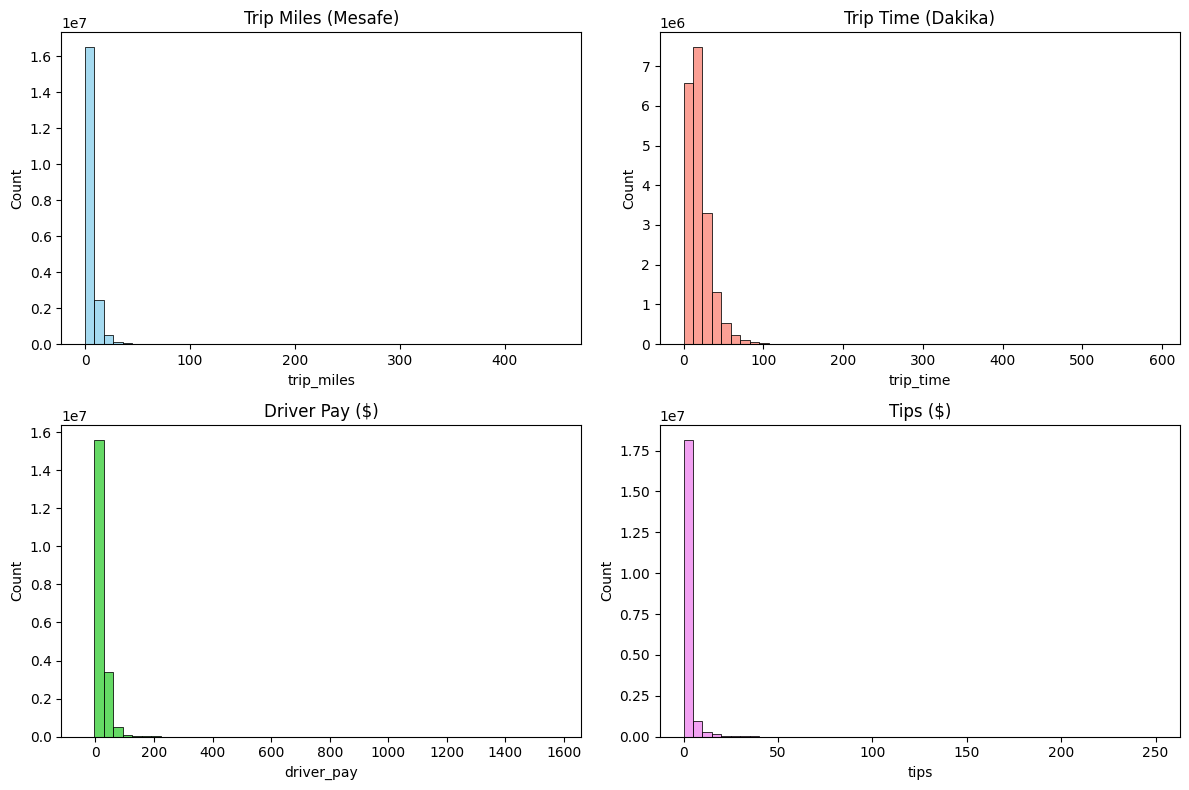

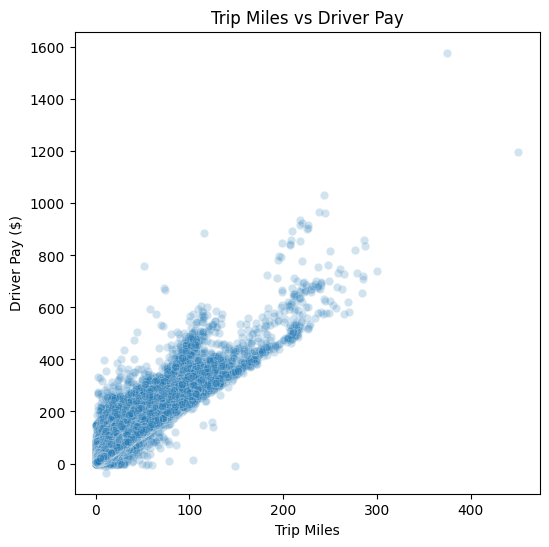

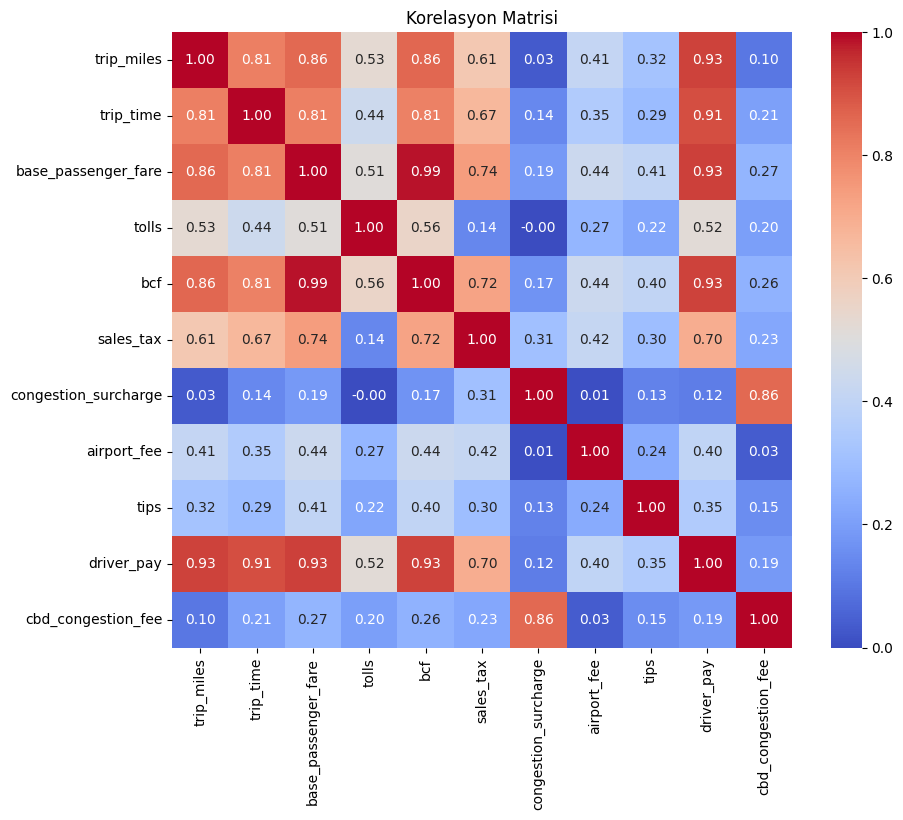

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Histogramlar
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["trip_miles"], bins=50, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Trip Miles (Mesafe)")

sns.histplot(df["trip_time"]/60, bins=50, ax=axes[0,1], color="salmon")
axes[0,1].set_title("Trip Time (Dakika)")

sns.histplot(df["driver_pay"], bins=50, ax=axes[1,0], color="limegreen")
axes[1,0].set_title("Driver Pay ($)")

sns.histplot(df["tips"], bins=50, ax=axes[1,1], color="violet")
axes[1,1].set_title("Tips ($)")

plt.tight_layout()
plt.show()

# 2) Scatterplot: mesafe vs şoför ücreti
plt.figure(figsize=(6,6))
sns.scatterplot(x=df["trip_miles"], y=df["driver_pay"], alpha=0.2)
plt.xlabel("Trip Miles")
plt.ylabel("Driver Pay ($)")
plt.title("Trip Miles vs Driver Pay")
plt.show()

# 3) Korelasyon matrisi (heatmap)
num_cols = ["trip_miles","trip_time","base_passenger_fare","tolls","bcf",
            "sales_tax","congestion_surcharge","airport_fee","tips","driver_pay","cbd_congestion_fee"]

corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Korelasyon Matrisi")
plt.show()


🌱 süper, şimdi grafiklerini tek tek yorumlayalım:

---

## 🔹 1. Histogramlar

* **Trip Miles** → Çoğu yolculuk **0–10 mil** arası. 100+ mil nadir (uç değerler).
* **Trip Time (dakika)** → Çoğu yolculuk **0–60 dk**. 100+ dk seyrek. Bu NYC için normal.
* **Driver Pay** → Çoğu yolculuk **0–50 \$** arası. 200+ \$ nadir (uç değerler).
* **Tips** → Çoğu yolculukta **0 bahşiş**. Bahşiş verenler az; bazen çok yüksek bahşiş var (ör. 100+ \$ ama nadir).

👉 Genel dağılımlar çok **sağa çarpık** (right-skewed). Yani “tipik değerler küçük, ama nadir büyük değerler var.”

---

## 🔹 2. Scatterplot (Trip Miles vs Driver Pay)

* Güzel **pozitif ilişki**: mesafe arttıkça ücret de artıyor.
* Ama çizgi tam düz değil → çünkü ücret sadece mesafeye değil, **zamana, vergi/surcharge, bahşiş** gibi şeylere de bağlı.
* Üst tarafta 100–400 mil arası birkaç “uç nokta” var → temizleme adımlarında işaretlediğin outlier’lar.

👉 Bu grafik **ekonomik mantığı doğruluyor**: daha uzun mesafe → daha çok kazanç.

---

## 🔹 3. Korelasyon matrisi

* **Çok güçlü korelasyonlar (0.9+)**:

  * `trip_miles` ↔ `base_passenger_fare` ↔ `driver_pay` ↔ `bcf`
    👉 Bunlar neredeyse aynı bilgiyi taşıyor.
* **Yüksek korelasyon (0.8+)**:

  * `trip_miles` ↔ `trip_time` → uzun mesafe = uzun süre.
* **Düşük korelasyon (<0.3)**:

  * `tips` → bağımsız, başka şeylere çok bağlı değil (müşteri davranışı).
  * `congestion_surcharge`, `airport_fee` → bağımsız.

👉 Demek ki:

* **Modelleme/analiz yaparken** her korele sütunu birlikte kullanmaya gerek yok (ör. `trip_miles` + `trip_time` + `base_passenger_fare` aynı anda fazla).
* Ama **tips** veya **fees** gibi sütunlar ekstra bilgi katıyor.

---

## 📌 Genel Yorum

* Verin **beklendiği gibi** davrandı:

  * Çoğu yolculuk kısa mesafe, kısa süre, düşük ücret.
  * Mesafe ve süre çok korele → mantıklı.
  * Şoför ücreti mesafe/süre ile yüksek korele.
  * Bahşiş ve ek ücretler bağımsız (sürpriz faktör).

---

👉 Bu noktadan sonra yapabileceğimiz şey:

1. **Feature Engineering** → yeni sütunlar (ör. `pay_per_mile`, `pay_per_hour`, `avg_speed`).
2. Bu yeni sütunlarla tekrar **EDA** (histogram, scatter, korelasyon).

---

Sana sorayım: İstersen şimdi **ilk Feature Engineering sütunlarını** (saatlik ücret, mil başı ücret, ortalama hız) ekleyelim mi?


🌱 çok güzel bir Data Engineering sorusu soruyorsun: “Korelasyon eşiğini nereden almalıyım, hangi değerleri yeni feature için incelemeye değer bulmalıyım?”

---

## 🔹 Genel pratik yaklaşım

* **0.00 – 0.30 → zayıf**
  👉 Çoğunlukla dikkate almaya değmez. Ama bazen sürpriz bilgi olabilir (ör. tips).

* **0.30 – 0.50 → orta**
  👉 İncelemeye değer. Çünkü ilişki var ama çok güçlü değil, bu da ek bilgi taşıyabileceğini gösterir.

* **0.50 – 0.70 → güçlü**
  👉 Kesinlikle anlamlı. Bu seviyede bir ilişki yeni feature için iyi adaydır.

* **0.70 – 0.90 → çok güçlü**
  👉 Zaten çok benzer bilgi. Yeni feature yaratmak yerine, belki **feature selection** yapman gerekir (birini at).

* **0.90+ → neredeyse aynı**
  👉 Yeni feature için **anlamsız**, çünkü duplicate bilgi.

---

## 🔹 Data Engineer bakış açısı

* Eğer **yeni feature arıyorsan**:

  * **0.3 ve üstünü** işaretle, “bunlar arasında bir bilgi ilişkisi var” de.
  * Özellikle **0.5–0.7** arası olanları ciddi düşün.

* Eğer **feature selection / veri indirgeme yapıyorsan**:

  * **0.8+** korelasyonlu sütunlardan birini atmayı düşün.

---

## 📌 Özet önerim sana

* **Yeni feature keşfi için**: **0.3+** ilişkileri incelemeye başla.
* **Feature seçerken**: **0.8+** olanlardan birini at.

👉 Yani Data Engineer olarak **çift yönlü düşünmen** lazım:

* Orta seviyeden itibaren incele (0.3–0.7).
* Çok yüksek olursa (0.8–1.0) → belki ele.

---

İstersen sana ben bir “korelasyon pipeline” yazayım:

* Tüm çiftleri hesaplasın,
* 0.3–0.7 arası olanları “potansiyel yeni feature ilişkisi” olarak işaretlesin,
* 0.8+ olanları “fazla benzer, dikkat” olarak listeleyelim.

👉 İstiyor musun böyle bir otomatik özet tablo?


In [20]:
# Korelasyon tablosunu uzun formatta gösterelim
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]

# Aynı sütunları veya tekrar edenleri çıkar
corr_pairs = corr_pairs[corr_pairs["Feature1"] < corr_pairs["Feature2"]]

# En yüksek 10 korelasyonu sırala
top_corr = corr_pairs.sort_values(by="Correlation", ascending=False).head(40)
print(top_corr)


                 Feature1              Feature2  Correlation
26    base_passenger_fare                   bcf         0.99
31    base_passenger_fare            driver_pay         0.93
99             driver_pay            trip_miles         0.93
53                    bcf            driver_pay         0.93
100            driver_pay             trip_time         0.91
44                    bcf            trip_miles         0.86
116    cbd_congestion_fee  congestion_surcharge         0.86
22    base_passenger_fare            trip_miles         0.86
23    base_passenger_fare             trip_time         0.81
1              trip_miles             trip_time         0.81
45                    bcf             trip_time         0.81
27    base_passenger_fare             sales_tax         0.74
49                    bcf             sales_tax         0.72
104            driver_pay             sales_tax         0.70
56              sales_tax             trip_time         0.67
55              sales_ta

🌱 süper kritik noktaya dokundun: **korelasyon katsayısını (r)** nasıl yorumlayacağımız.

---

## 🔹 Korelasyon katsayısı (r) aralıkları

Korelasyon **–1 ile +1** arasında değişir. Matematikte yorumu:

* **0.00 – 0.10** → ihmal edilebilir (çok zayıf)
* **0.10 – 0.30** → zayıf ilişki
* **0.30 – 0.50** → orta ilişki
* **0.50 – 0.70** → güçlü ilişki
* **0.70 – 0.90** → çok güçlü ilişki
* **0.90+** → neredeyse aynı bilgi (multicollinearity riski)

👉 Bu aralıklar istatistik kitaplarında “rule of thumb” (genel kural) olarak verilir. Keskin bir matematiksel sınır yoktur, ama pratikte böyle kabul edilir.

---

## 🔹 Neden 0.9+ “sorun” olabilir?

* Çünkü 0.91 → “neredeyse aynı değişken” demektir.
* Örneğin `trip_miles` ve `driver_pay` zaten aynı şeyi anlatıyor olabilir (sadece para birimi farkı gibi).
* Model kurarken ikisini birden koyarsan **multicollinearity** oluşur → model şişer, anlamlı yorum yapamazsın.

---

## 🔹 Peki 0.8–0.85 ne demek?

* Bu hâlâ **çok güçlü ilişki** ama tam kopya değil.
* Burada karar verilir:

  * Eğer analiz → kullanıcı hikâyeleri için, bırakabilirsin.
  * Eğer modelleme (regresyon, ML) yapıyorsan → genelde birini seçmek daha iyi.

---

## 🔹 Matematiksel dayanak

* Korelasyon katsayısı, iki değişkenin **lineer bağıntı gücünü** ölçer:

  $$
  r = \frac{\text{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y}
  $$
* Yani r=1 → X ve Y tamamen aynı doğrusal çizgide.
* r=0.9 → X artarken Y %90 “benzer bir şekilde” artıyor.
* İstatistikte r² (determinasyon katsayısı) da kullanılır:

  * r=0.9 → r²=0.81 → Y’nin varyansının %81’i X tarafından açıklanıyor.
  * r=0.8 → r²=0.64 → %64’ü açıklanıyor.

---

## 📌 Özet

* **0.9+** → genelde “fazla benzer” → dikkat (multicollinearity).
* **0.7–0.9** → çok güçlü ilişki → analiz için önemli, ama modele koyarken dikkat.
* **0.5–0.7** → güçlü, anlamlı ilişki.
* **<0.3** → zayıf, genelde ihmal edilebilir.

---

👉 Yani senin soruna net cevap:

* **0.91 “sacma” değil, ama fazla güçlü → aynı bilgi olabilir.**
* **0.8–0.85 arası** → hâlâ önemli ilişki, ama belki farklı bakış açıları getirir.

---

Sana bir tablo halinde özetlememi ister misin? (korelasyon aralığı → anlamı → User Story için yorumu)


🌱 harika, yaptın! Şimdi sıra geldi **yorumlama aşamasına**. Artık tablo elinde:

---

## 🔹 1. high\_corr (≥0.8)

* Bu tablo sana şunu söylüyor:

  * Bu sütun çiftleri **neredeyse aynı şeyi anlatıyor**.
  * Örn: `trip_miles` ↔ `trip_time`, `base_passenger_fare` ↔ `driver_pay`.
* Burada Data Engineer olarak yapacağın şey:

  * Eğer model kuracaksan → aynı anda koyma, birini seç.
  * Eğer sadece analiz yapıyorsan → bunların benzer olduğunu bil, yorumunu buna göre yap.

---

## 🔹 2. mid\_corr (0.3 – 0.8)

* Bu tablo daha heyecanlı çünkü **yeni bilgi potansiyeli burada**.
* Örn: `tips` ↔ `driver_pay` belki 0.35–0.4 → zayıf ama anlamlı bir ilişki.
* `tolls` ↔ `trip_miles` orta seviye olabilir (uzun yol → daha çok köprü/otoyol).
* İşte buradan yeni feature fikirleri çıkar:

  * `tips_ratio = tips / driver_pay`
  * `tolls_per_mile = tolls / trip_miles`
  * `effective_pay_per_hour = (driver_pay + tips) / (trip_time/3600)`

---

## 🔹 3. Şimdi ne yapmalısın?

1. **high\_corr tablosunu** gözden geçir:

   * “Bu kolonlar redundant, model kurarken ikisini birden kullanmam.”
2. **mid\_corr tablosunu** incele:

   * “Bunların ilişkisini daha iyi anlamak için yeni türev sütun ekleyebilir miyim?”
   * Örn: tips & driver\_pay → “tip oranı”
   * trip\_time & trip\_miles → “ortalama hız”

---

📌 Yani: **evet, şimdi senin düşünmen gerek** 🙌

* Hangi ilişkiler redundant?
* Hangi orta seviyeli ilişkiler yeni feature çıkarmaya değer?

---

👉 İstersen ben sana senin User Story’lerine göre (Angebot/Nachfrage, Einnahmen, Lohn) **hangi mid\_corr ilişkilerinden yeni feature çıkarılabilir** onun öneri listesini yapayım mı?


In [22]:
import pandas as pd

# 1) Sadece sayısal kolonlardan korelasyon matrisi
num_cols = [
    "trip_miles","trip_time","base_passenger_fare","tolls","bcf",
    "sales_tax","congestion_surcharge","airport_fee","tips","driver_pay","cbd_congestion_fee"
]
corr = df[num_cols].corr()

# 2) Uzun form (Feature1-Feature2-Correlation)
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]

# Aynı çiftleri ve diagonal'i at (A-B ile B-A tekrar etmesin, A-A olmasın)
corr_pairs = corr_pairs[corr_pairs["Feature1"] < corr_pairs["Feature2"]]

# 3) Eşiklere göre filtrele
mid_corr  = corr_pairs[(corr_pairs["Correlation"] >= 0.3) & (corr_pairs["Correlation"] < 0.8)] \
                      .sort_values(by="Correlation", ascending=False)
high_corr = corr_pairs[corr_pairs["Correlation"] >= 0.8] \
                      .sort_values(by="Correlation", ascending=False)

# 4) Sonuçları göster
print("Top 10 en yüksek korelasyon (genelde redundant riski):")
print(high_corr.head(10), "\n")

print("Top 15 orta-yüksek korelasyon (incelemeye değer, yeni feature fikirleri):")
print(mid_corr.head(15), "\n")

print(f"high_corr satır sayısı: {len(high_corr)}  |  mid_corr satır sayısı: {len(mid_corr)}")

# 5) (Opsiyonel) CSV çıkışı
high_corr.to_csv("high_corr_pairs.csv", index=False)
mid_corr.to_csv("mid_corr_pairs.csv", index=False)
print("Kaydedildi: high_corr_pairs.csv, mid_corr_pairs.csv")



Top 10 en yüksek korelasyon (genelde redundant riski):
                Feature1              Feature2  Correlation
26   base_passenger_fare                   bcf         0.99
31   base_passenger_fare            driver_pay         0.93
99            driver_pay            trip_miles         0.93
53                   bcf            driver_pay         0.93
100           driver_pay             trip_time         0.91
44                   bcf            trip_miles         0.86
116   cbd_congestion_fee  congestion_surcharge         0.86
22   base_passenger_fare            trip_miles         0.86
23   base_passenger_fare             trip_time         0.81
1             trip_miles             trip_time         0.81 

Top 15 orta-yüksek korelasyon (incelemeye değer, yeni feature fikirleri):
                Feature1             Feature2  Correlation
27   base_passenger_fare            sales_tax         0.74
49                   bcf            sales_tax         0.72
104           driver_pay        

3. Şimdi ne yapmalısın?

high_corr tablosunu gözden geçir:

“Bu kolonlar redundant, model kurarken ikisini birden kullanmam.”

mid_corr tablosunu incele:

“Bunların ilişkisini daha iyi anlamak için yeni türev sütun ekleyebilir miyim?”

Örn: tips & driver_pay → “tip oranı”

trip_time & trip_miles → “ortalama hız”

📌 Yani: evet, şimdi senin düşünmen gerek 🙌

Hangi ilişkiler redundant?

Hangi orta seviyeli ilişkiler yeni feature çıkarmaya değer?